# AttentionUNet — Salem Mineral Segmentation (Raw 7 Bands + PCA Top3 + 5 Geo = 15 Channels)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1")
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1


### Imports & Reproducibility

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')

import rasterio as rio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import albumentations as A

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
_g = torch.Generator()
_g.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


### Configuration

In [3]:
# ── Paths
BASE_DIR      = Path("/content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1")
BASE_NAME     = 'LC08_L2SP_143052_20230213_20230218_02_T1'
BASE_NAME_ALL = 'RAW_PCA_GEO(15)'

# ── Raw 7-band array
RAW_NPY  = BASE_DIR / 'salem_multispectral_cropped_8.npy'   # (7, H, W) raw Landsat-8 bands
RAW_TIF  = BASE_DIR / 'salem_multispectral_cropped_8.tif'   # spatial metadata only

# ── PCA top-3 GeoTIFF files
PCA_FILES = [
    BASE_DIR / 'salem_PC1.tif',
    BASE_DIR / 'salem_PC2.tif',
    BASE_DIR / 'salem_PC3.tif',
]

# ── 5 geo-feature rasters (clipped to Salem & aligned)
GEO_TIFS = [
    BASE_DIR / 'LITHOLOGIC.tif',
    BASE_DIR / 'INTRUSIVE.tif',
    BASE_DIR / 'AGE.tif',
    BASE_DIR / 'GROUP_NAME.tif',
    BASE_DIR / 'DISTANCE_TO_FAULT.tif',
]

MASK_NPY  = BASE_DIR / 'salem_valid_mask_8.npy'               # (H, W) bool
LABEL_NPY = BASE_DIR / 'salem_Minerals_binary_labels_8.npy'

# ── Patch settings
PATCH_SIZE   = 128
STRIDE       = 32
NAN_THRESH   = 0.30

# ── 7 raw + 3 PCA + 5 geo = 15 channels
IN_CHANNELS  = 15
NUM_CLASSES  = 1        # binary segmentation

# ── Training  (same hyperparameters as before)
BATCH_SIZE   = 16
NUM_EPOCHS   = 100
TRAIN_SPLIT  = 0.70
VAL_SPLIT    = 0.15     # test = 1 - 0.70 - 0.15 = 0.15

THRESHOLD    = 0.3

# ── Output dirs
PATCH_DIR    = BASE_DIR / 'patches_raw_pca_geo_final'
CKPT_PATH    = BASE_DIR / 'best_AttentionUNet_minerals_raw_pca_geo_final.pth'
RESULTS_DIR  = BASE_DIR / 'results_raw_pca_geo_final'

PATCH_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("15-channel configuration loaded.")
print(f"  Input channels : {IN_CHANNELS}  (7 raw Landsat-8 + 3 PCA top bands + 5 geo-feature rasters)")
print(f"  RAW bands      : salem_multispectral_cropped_8.npy")
print(f"  PCA files      : {[p.name for p in PCA_FILES]}")
print(f"  GEO files      : {[p.name for p in GEO_TIFS]}")
print(f"  Patch size     : {PATCH_SIZE}\u00d7{PATCH_SIZE}")
print(f"  Stride         : {STRIDE}")
print(f"  Train/Val/Test : {TRAIN_SPLIT}/{VAL_SPLIT}/{1-TRAIN_SPLIT-VAL_SPLIT:.2f}")
print(f"  Train threshold: {THRESHOLD}")

15-channel configuration loaded.
  Input channels : 15  (7 raw Landsat-8 + 3 PCA top bands + 5 geo-feature rasters)
  RAW bands      : salem_multispectral_cropped_8.npy
  PCA files      : ['salem_PC1.tif', 'salem_PC2.tif', 'salem_PC3.tif']
  GEO files      : ['LITHOLOGIC.tif', 'INTRUSIVE.tif', 'AGE.tif', 'GROUP_NAME.tif', 'DISTANCE_TO_FAULT.tif']
  Patch size     : 128×128
  Stride         : 32
  Train/Val/Test : 0.7/0.15/0.15
  Train threshold: 0.3


### Load Raw 7 Bands + PCA Top3 Bands + Geo-Feature Rasters + Valid Mask + Labels

In [4]:
import gc

# =============================================================================
# STEP 1 — Load Raw 7 Bands
# =============================================================================
print("STEP 1: Loading raw 7-band array...")

raw_stack = np.load(RAW_NPY).astype(np.float32)

# Auto-detect and fix channel dimension order → (H, W, 7)
if raw_stack.ndim == 3 and raw_stack.shape[0] == 7:
    print(f"  Detected channels-first format {raw_stack.shape}, transposing to channels-last")
    raw_stack = np.transpose(raw_stack, (1, 2, 0))   # (7, H, W) → (H, W, 7)

H, W, _ = raw_stack.shape
print(f"  Raw-band stack shape : {raw_stack.shape}")   # (H, W, 7)

# ── Load valid mask
valid_mask = np.load(MASK_NPY).astype(bool)             # (H, W)
print(f"  Valid mask shape     : {valid_mask.shape}")

assert raw_stack.shape[:2] == valid_mask.shape, (
    f"Shape mismatch! Raw stack {raw_stack.shape[:2]} != mask {valid_mask.shape}"
)

# Apply valid mask: set invalid pixels to NaN
for b in range(raw_stack.shape[-1]):
    raw_stack[:, :, b][~valid_mask] = np.nan
print(f"  Valid mask applied to raw bands.")

# ── Load spatial metadata from GeoTIFF
with rio.open(RAW_TIF) as src:
    landsat_transform = src.transform
    landsat_crs       = src.crs
    landsat_profile   = src.profile.copy()
    landsat_profile.update({'height': H, 'width': W, 'count': 1, 'transform': landsat_transform})
print("  Spatial metadata loaded from GeoTIFF.")

# =============================================================================
# STEP 2 — Load PCA Top-3 Bands from individual GeoTIFFs
# =============================================================================
print("\nSTEP 2: Loading PCA top-3 GeoTIFF files...")

pca_channels = []
pca_names    = ['PC1', 'PC2', 'PC3']

for tif_path, pc_name in zip(PCA_FILES, pca_names):
    with rio.open(tif_path) as src:
        arr = src.read(1).astype(np.float32)   # (H, W)
    assert arr.shape == (H, W), (
        f"Shape mismatch for {pc_name}: got {arr.shape}, expected ({H}, {W})"
    )
    arr[~valid_mask] = np.nan
    pca_channels.append(arr)
    print(f"  Loaded {pc_name} from {tif_path.name}: "          f"range=[{np.nanmin(arr):.4f}, {np.nanmax(arr):.4f}]")

# Stack PCA channels → (H, W, 3)
pca_stack = np.stack(pca_channels, axis=-1)   # (H, W, 3)
del pca_channels
gc.collect()
print(f"  PCA stack shape : {pca_stack.shape}")

# =============================================================================
# STEP 3 — Load 5 Geo-Feature Rasters
# =============================================================================
print("\nSTEP 3: Loading geo-feature rasters...")

GEO_NAMES    = ['Lithology', 'Intrusive', 'Age', 'Group', 'Dist_to_Fault']
geo_channels = []

for tif_path, name in zip(GEO_TIFS, GEO_NAMES):
    with rio.open(tif_path) as src:
        arr = src.read(1).astype(np.float32)   # (H, W)
    assert arr.shape == (H, W), (
        f"Shape mismatch for {name}: got {arr.shape}, expected ({H}, {W})"
    )
    arr[~valid_mask] = np.nan
    geo_channels.append(arr)
    print(f"  Loaded {name}: range [{np.nanmin(arr):.4f}, {np.nanmax(arr):.4f}]")

# Stack geo channels → (H, W, 5)
geo_stack = np.stack(geo_channels, axis=-1)   # (H, W, 5)
del geo_channels
gc.collect()
print(f"  Geo stack shape : {geo_stack.shape}")

# =============================================================================
# STEP 4 — Concatenate all: raw (H,W,7) + pca (H,W,3) + geo (H,W,5) → (H,W,15)
# =============================================================================
print("\nSTEP 4: Concatenating all feature stacks...")

full_stack = np.concatenate([raw_stack, pca_stack, geo_stack], axis=-1)   # (H, W, 15)
del raw_stack, pca_stack, geo_stack
gc.collect()

H, W, C = full_stack.shape
print(f"  Channel layout   : 7 raw | 3 PCA | 5 geo = {C} total")
print(f"  Full stack shape : {full_stack.shape}  (H, W, {C})")
print(f"  Valid pixels     : {np.sum(valid_mask):,} ({100*np.sum(valid_mask)/valid_mask.size:.2f}%)")

# =============================================================================
# STEP 5 — Load Binary Labels
# =============================================================================
print("\nSTEP 5: Loading binary labels...")

binary_labels = np.load(LABEL_NPY).astype(np.uint8)   # (H, W)

if binary_labels.shape != valid_mask.shape:
    raise ValueError(
        f"Shape mismatch! Label {binary_labels.shape} vs mask {valid_mask.shape}."
    )

binary_labels[~valid_mask] = 0

# ── Class statistics
total_px   = int(np.sum(valid_mask))
mineral_px = int(np.sum((binary_labels == 1) & valid_mask))
bg_px      = total_px - mineral_px
ratio      = bg_px / (mineral_px + 1e-8)

print("\nAfter valid-mask application:")
print(f"  Valid pixels    : {total_px:,}")
print(f"  Mineral pixels  : {mineral_px:,} ({mineral_px/total_px*100:.4f}%)")
print(f"  Background px   : {bg_px:,}")
print(f"  Imbalance ratio : {ratio:.0f} : 1")

STEP 1: Loading raw 7-band array...
  Detected channels-first format (7, 2455, 4327), transposing to channels-last
  Raw-band stack shape : (2455, 4327, 7)
  Valid mask shape     : (2455, 4327)
  Valid mask applied to raw bands.
  Spatial metadata loaded from GeoTIFF.

STEP 2: Loading PCA top-3 GeoTIFF files...
  Loaded PC1 from salem_PC1.tif: range=[-6.9559, 40.6787]
  Loaded PC2 from salem_PC2.tif: range=[-7.4825, 6.3957]
  Loaded PC3 from salem_PC3.tif: range=[-24.5666, 11.3568]
  PCA stack shape : (2455, 4327, 3)

STEP 3: Loading geo-feature rasters...
  Loaded Lithology: range [1.0000, 34.0000]
  Loaded Intrusive: range [0.0000, 5.0000]
  Loaded Age: range [1.0000, 6.0000]
  Loaded Group: range [0.0000, 8.0000]
  Loaded Dist_to_Fault: range [0.0000, 0.9206]
  Geo stack shape : (2455, 4327, 5)

STEP 4: Concatenating all feature stacks...
  Channel layout   : 7 raw | 3 PCA | 5 geo = 15 total
  Full stack shape : (2455, 4327, 15)  (H, W, 15)
  Valid pixels     : 5,794,980 (54.55%)

S

### Spatial Block Split + Patch Extraction (No Overlap)

In [5]:
MIN_MINERAL_FRAC   = 0.001  # ≥0.5% mineral pixels - mineral patch
MAX_BG_RATIO       = 2      # max bg patches per mineral patch (per split)
NON_OVERLAP_STRIDE = 64     # 50% overlap

# ── Augmentation counts
N_AUG_MINERAL = 10   # each mineral patch - 8 augmented copies
N_AUG_BG      = 3   # each bg patch      - 3 augmented copies

# ── Channel names for all 15 channels
band_names = [
    'B1 (Coastal)', 'B2 (Blue)',  'B3 (Green)', 'B4 (Red)',
    'B5 (NIR)',     'B6 (SWIR1)', 'B7 (SWIR2)',
    'PC1',          'PC2',        'PC3',
    'Lithology',    'Intrusive',  'Age',
    'Group',        'Dist_Fault'
]

print('PATCH EXTRACTION — Non-overlapping stride (zero leakage)')
print(f'  Patch size       : {PATCH_SIZE}×{PATCH_SIZE}')
print(f'  Stride           : {NON_OVERLAP_STRIDE}')
print(f'  Min mineral frac : {MIN_MINERAL_FRAC}')
print(f'  Mineral aug      : {N_AUG_MINERAL}× per patch (train only)')
print(f'  Background aug   : {N_AUG_BG}× per patch (train only)')

# ── Extract ALL valid patches with non-overlapping stride
H_img, W_img = full_stack.shape[:2]

all_mineral_imgs, all_mineral_lbls, all_mineral_valid, all_mineral_pos = [], [], [], []
all_bg_imgs,      all_bg_lbls,      all_bg_valid,      all_bg_pos      = [], [], [], []
total_candidates = skipped_nan = 0

for r in range(0, H_img - PATCH_SIZE + 1, NON_OVERLAP_STRIDE):
    for c in range(0, W_img - PATCH_SIZE + 1, NON_OVERLAP_STRIDE):
        total_candidates += 1
        img_p = full_stack[r:r+PATCH_SIZE, c:c+PATCH_SIZE, :].copy()
        lbl_p = binary_labels[r:r+PATCH_SIZE, c:c+PATCH_SIZE].copy()

        nan_frac = np.isnan(img_p).any(axis=-1).mean()
        if nan_frac > NAN_THRESH:
            skipped_nan += 1
            continue

        # Capture per-patch valid pixel mask BEFORE filling NaNs
        valid_p = (~np.isnan(img_p).any(axis=-1)).astype(np.uint8)  # (H, W) uint8

        img_p = np.nan_to_num(img_p, nan=0.0)

        if lbl_p.mean() >= MIN_MINERAL_FRAC:
            all_mineral_imgs.append(img_p)
            all_mineral_lbls.append(lbl_p)
            all_mineral_valid.append(valid_p)
            all_mineral_pos.append((r, c))
        elif img_p.max() > 0:
            all_bg_imgs.append(img_p)
            all_bg_lbls.append(lbl_p)
            all_bg_valid.append(valid_p)
            all_bg_pos.append((r, c))

print(f'\nTotal candidates   : {total_candidates}')
print(f'Skipped (NaN>30%)  : {skipped_nan}')
print(f'Mineral patches    : {len(all_mineral_imgs)}')
print(f'Background patches : {len(all_bg_imgs)}')

if len(all_mineral_imgs) == 0:
    raise ValueError('No mineral patches found! Check MIN_MINERAL_FRAC or NAN_THRESH.')


# ── Stratified split of MINERAL patches
mineral_fracs = np.array([lbl.mean() for lbl in all_mineral_lbls])
strat_bins    = np.digitize(mineral_fracs, bins=[0.05, 0.15, 0.30, 0.50])

all_idx = np.arange(len(all_mineral_imgs))

train_idx, temp_idx = train_test_split(
    all_idx,
    test_size=(VAL_SPLIT + (1 - TRAIN_SPLIT - VAL_SPLIT)),
    stratify=strat_bins,
    random_state=SEED
)

temp_strat = strat_bins[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_strat,
    random_state=SEED
)

print(f'\nMineral patch split (stratified by mineral fraction):')
print(f'  Train : {len(train_idx):4d}  ({len(train_idx)/len(all_idx)*100:.1f}%)')
print(f'  Val   : {len(val_idx):4d}  ({len(val_idx)/len(all_idx)*100:.1f}%)')
print(f'  Test  : {len(test_idx):4d}  ({len(test_idx)/len(all_idx)*100:.1f}%)')


# ── Verify zero pixel overlap between splits
train_pos_set = set(all_mineral_pos[i] for i in train_idx)
val_pos_set   = set(all_mineral_pos[i] for i in val_idx)
test_pos_set  = set(all_mineral_pos[i] for i in test_idx)

assert len(train_pos_set & val_pos_set)  == 0, 'Train/Val mineral overlap!'
assert len(train_pos_set & test_pos_set) == 0, 'Train/Test mineral overlap!'
assert len(val_pos_set   & test_pos_set) == 0, 'Val/Test mineral overlap!'
print('\n Zero-overlap verified: no patch origin shared between any two splits.')


# ── Split background patches
rng    = np.random.default_rng(SEED)
bg_idx = rng.permutation(len(all_bg_imgs))

n_bg       = len(bg_idx)
n_bg_train = int(n_bg * TRAIN_SPLIT)
n_bg_val   = int(n_bg * VAL_SPLIT)

bg_train_idx = bg_idx[:n_bg_train]
bg_val_idx   = bg_idx[n_bg_train : n_bg_train + n_bg_val]
bg_test_idx  = bg_idx[n_bg_train + n_bg_val:]

def cap_bg(bg_indices, n_mineral, max_ratio, rng):
    max_bg = min(len(bg_indices), max(max_ratio, max_ratio * n_mineral))
    return rng.choice(bg_indices, size=int(max_bg), replace=False)

bg_train_idx = cap_bg(bg_train_idx, len(train_idx), MAX_BG_RATIO, rng)
bg_val_idx   = cap_bg(bg_val_idx,   len(val_idx),   MAX_BG_RATIO, rng)
bg_test_idx  = cap_bg(bg_test_idx,  len(test_idx),  MAX_BG_RATIO, rng)

print(f'\nBackground patches after cap (max {MAX_BG_RATIO}× mineral):')
print(f'  Train bg : {len(bg_train_idx)}')
print(f'  Val   bg : {len(bg_val_idx)}')
print(f'  Test  bg : {len(bg_test_idx)}')

split_data = {
    'train': {
        'mineral_imgs':   [all_mineral_imgs[i]   for i in train_idx],
        'mineral_lbls':   [all_mineral_lbls[i]   for i in train_idx],
        'mineral_valids': [all_mineral_valid[i]  for i in train_idx],
        'bg_imgs':        [all_bg_imgs[i]         for i in bg_train_idx],
        'bg_lbls':        [all_bg_lbls[i]         for i in bg_train_idx],
        'bg_valids':      [all_bg_valid[i]        for i in bg_train_idx],
    },
    'val': {
        'mineral_imgs':   [all_mineral_imgs[i]   for i in val_idx],
        'mineral_lbls':   [all_mineral_lbls[i]   for i in val_idx],
        'mineral_valids': [all_mineral_valid[i]  for i in val_idx],
        'bg_imgs':        [all_bg_imgs[i]         for i in bg_val_idx],
        'bg_lbls':        [all_bg_lbls[i]         for i in bg_val_idx],
        'bg_valids':      [all_bg_valid[i]        for i in bg_val_idx],
    },
    'test': {
        'mineral_imgs':   [all_mineral_imgs[i]   for i in test_idx],
        'mineral_lbls':   [all_mineral_lbls[i]   for i in test_idx],
        'mineral_valids': [all_mineral_valid[i]  for i in test_idx],
        'bg_imgs':        [all_bg_imgs[i]         for i in bg_test_idx],
        'bg_lbls':        [all_bg_lbls[i]         for i in bg_test_idx],
        'bg_valids':      [all_bg_valid[i]        for i in bg_test_idx],
    },
}

print('\n── Split summary (pre-augmentation) ──')
for sname, sd in split_data.items():
    n_min = len(sd['mineral_imgs'])
    n_bg  = len(sd['bg_imgs'])
    print(f'  {sname:5s} | mineral={n_min:4d} | bg={n_bg:4d} | total={n_min+n_bg}')

del all_mineral_imgs, all_mineral_lbls, all_mineral_pos
del all_bg_imgs, all_bg_lbls, all_bg_pos
gc.collect()


# ── Compute per-channel normalization stats from ORIGINAL train patches
tr_d = split_data['train']
orig_train_imgs = np.array(
    tr_d['mineral_imgs'] + tr_d['bg_imgs'], dtype=np.float32
)  # (N_orig, H, W, 12)

band_means_list, band_stds_list = [], []
print(f'\nComputing per-channel stats from {len(orig_train_imgs)} ORIGINAL train patches...')
for c in range(IN_CHANNELS):
    vals = orig_train_imgs[:, :, :, c].ravel()
    vals = vals[np.isfinite(vals)]
    m    = float(vals.mean())
    s    = float(vals.std()) + 1e-8
    band_means_list.append(m)
    band_stds_list.append(s)
    print(f'  {band_names[c]:<20} | mean = {m:10.4f} | std = {s:10.4f}')

band_means = np.array(band_means_list, dtype=np.float32)
band_stds  = np.array(band_stds_list,  dtype=np.float32)
del orig_train_imgs
gc.collect()
print('Normalization stats computed from original (pre-augmentation) train patches.')


# ── Albumentations augmentation pipeline
_aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.5),
    A.GaussNoise(var_limit=(1e-6, 9e-6), p=0.3),  # very mild spectral noise
], additional_targets={'mask': 'mask', 'valid_mask': 'mask'})


def augment_patches(imgs, lbls, valids, n_augments, seed_offset=0):
    aug_imgs, aug_lbls, aug_valids = [], [], []
    for idx, (img, lbl, valid) in enumerate(zip(imgs, lbls, valids)):
        for k in range(n_augments):
            random.seed(SEED + seed_offset + idx * 100 + k)
            np.random.seed(SEED + seed_offset + idx * 100 + k)
            result  = _aug_pipeline(image=img, mask=lbl.astype(np.uint8),
                                    valid_mask=valid.astype(np.uint8))
            aug_imgs.append(result['image'].copy())
            aug_lbls.append(result['mask'].copy())
            aug_valids.append(result['valid_mask'].copy())
    return aug_imgs, aug_lbls, aug_valids


# ── Augment TRAIN mineral patches
n_orig_mineral = len(tr_d['mineral_imgs'])

aug_min_imgs, aug_min_lbls, aug_min_valids = augment_patches(
    tr_d['mineral_imgs'],
    tr_d['mineral_lbls'],
    tr_d['mineral_valids'],
    n_augments=N_AUG_MINERAL,
    seed_offset=0
)

tr_min_all_imgs   = list(tr_d['mineral_imgs'])   + aug_min_imgs
tr_min_all_lbls   = list(tr_d['mineral_lbls'])   + aug_min_lbls
tr_min_all_valids = list(tr_d['mineral_valids']) + aug_min_valids

print(f'\nAugmented train MINERAL patches:')
print(f'  Original : {n_orig_mineral}')
print(f'  Aug only : {len(aug_min_imgs)}  ({N_AUG_MINERAL} copies × {n_orig_mineral})')
print(f'  Total    : {len(tr_min_all_imgs)}  (orig + aug)')


# ── Augment TRAIN background patches
n_orig_bg = len(tr_d['bg_imgs'])

aug_bg_imgs, aug_bg_lbls, aug_bg_valids = augment_patches(
    tr_d['bg_imgs'],
    tr_d['bg_lbls'],
    tr_d['bg_valids'],
    n_augments=N_AUG_BG,
    seed_offset=10000
)

tr_bg_all_imgs   = list(tr_d['bg_imgs'])   + aug_bg_imgs
tr_bg_all_lbls   = list(tr_d['bg_lbls'])   + aug_bg_lbls
tr_bg_all_valids = list(tr_d['bg_valids']) + aug_bg_valids

print(f'\nAugmented train BACKGROUND patches:')
print(f'  Original : {n_orig_bg}')
print(f'  Aug only : {len(aug_bg_imgs)}  ({N_AUG_BG} copies × {n_orig_bg})')
print(f'  Total    : {len(tr_bg_all_imgs)}  (orig + aug)')

del aug_min_imgs, aug_min_lbls, aug_min_valids, aug_bg_imgs, aug_bg_lbls, aug_bg_valids
gc.collect()


# ── Assemble final arrays
def assemble(min_imgs, min_lbls, min_valids, bg_imgs, bg_lbls, bg_valids):
    imgs   = np.concatenate([
        np.array(min_imgs,   dtype=np.float32),
        np.array(bg_imgs,    dtype=np.float32)
    ], axis=0)
    lbls   = np.concatenate([
        np.array(min_lbls,   dtype=np.uint8),
        np.array(bg_lbls,    dtype=np.uint8)
    ], axis=0)
    valids = np.concatenate([
        np.array(min_valids, dtype=np.uint8),
        np.array(bg_valids,  dtype=np.uint8)
    ], axis=0)
    return imgs, lbls, valids


train_imgs, train_lbls, train_valids = assemble(
    tr_min_all_imgs,   tr_min_all_lbls,   tr_min_all_valids,
    tr_bg_all_imgs,    tr_bg_all_lbls,    tr_bg_all_valids
)
val_imgs,   val_lbls,   val_valids   = assemble(
    split_data['val']['mineral_imgs'],   split_data['val']['mineral_lbls'],   split_data['val']['mineral_valids'],
    split_data['val']['bg_imgs'],        split_data['val']['bg_lbls'],        split_data['val']['bg_valids']
)
test_imgs,  test_lbls,  test_valids  = assemble(
    split_data['test']['mineral_imgs'],  split_data['test']['mineral_lbls'],  split_data['test']['mineral_valids'],
    split_data['test']['bg_imgs'],       split_data['test']['bg_lbls'],       split_data['test']['bg_valids']
)

del tr_min_all_imgs, tr_min_all_lbls, tr_min_all_valids
del tr_bg_all_imgs,  tr_bg_all_lbls,  tr_bg_all_valids
del split_data, tr_d
gc.collect()


# ── Build tags and shuffle train
def make_tags(lbl_arr):
    N = len(lbl_arr)
    return (lbl_arr.reshape(N, -1).sum(axis=1) > 0).astype(np.uint8)

train_tags = make_tags(train_lbls)
val_tags   = make_tags(val_lbls)
test_tags  = make_tags(test_lbls)

perm         = np.random.default_rng(SEED).permutation(len(train_imgs))
train_imgs   = train_imgs[perm]
train_lbls   = train_lbls[perm]
train_valids = train_valids[perm]
train_tags   = train_tags[perm]

# ── Print final dataset summary
print('\n── Final dataset sizes ──')
print(f'  Train : {len(train_imgs):>5} patches | '
      f'mineral={train_tags.sum():>4} ({train_tags.mean()*100:.1f}%) | '
      f'bg={len(train_imgs)-train_tags.sum()}')
print(f'  Val   : {len(val_imgs):>5} patches | '
      f'mineral={val_tags.sum():>4} ({val_tags.mean()*100:.1f}%) | '
      f'bg={len(val_imgs)-val_tags.sum()}')
print(f'  Test  : {len(test_imgs):>5} patches | '
      f'mineral={test_tags.sum():>4} ({test_tags.mean()*100:.1f}%) | '
      f'bg={len(test_imgs)-test_tags.sum()}')

print(f'\n  Train breakdown:')
print(f'    Mineral patches : {n_orig_mineral} orig + {n_orig_mineral * N_AUG_MINERAL} aug = {n_orig_mineral * (1 + N_AUG_MINERAL)}')
print(f'    Background patches : {n_orig_bg} orig + {n_orig_bg * N_AUG_BG} aug = {n_orig_bg * (1 + N_AUG_BG)}')
print(f'\n  Val and Test : ONLY original unaugmented patches from non-overlapping splits.')

# ── Save arrays
PATCH_DIR.mkdir(exist_ok=True)
np.save(PATCH_DIR / 'train_imgs_raw_pca_geo.npy',   train_imgs)
np.save(PATCH_DIR / 'train_lbls_raw_pca_geo.npy',   train_lbls)
np.save(PATCH_DIR / 'train_valids_raw_pca_geo.npy', train_valids)
np.save(PATCH_DIR / 'val_imgs_raw_pca_geo.npy',     val_imgs)
np.save(PATCH_DIR / 'val_lbls_raw_pca_geo.npy',     val_lbls)
np.save(PATCH_DIR / 'val_valids_raw_pca_geo.npy',   val_valids)
np.save(PATCH_DIR / 'test_imgs_raw_pca_geo.npy',    test_imgs)
np.save(PATCH_DIR / 'test_lbls_raw_pca_geo.npy',    test_lbls)
np.save(PATCH_DIR / 'test_valids_raw_pca_geo.npy',  test_valids)
np.save(PATCH_DIR / 'raw_pca_geo_means.npy', band_means)
np.save(PATCH_DIR / 'raw_pca_geo_stds.npy',  band_stds)
print('\nAll arrays and normalization stats saved.')

PATCH EXTRACTION — Non-overlapping stride (zero leakage)
  Patch size       : 128×128
  Stride           : 64
  Min mineral frac : 0.001
  Mineral aug      : 10× per patch (train only)
  Background aug   : 3× per patch (train only)

Total candidates   : 2442
Skipped (NaN>30%)  : 1126
Mineral patches    : 127
Background patches : 1189

Mineral patch split (stratified by mineral fraction):
  Train :   88  (69.3%)
  Val   :   19  (15.0%)
  Test  :   20  (15.7%)

 Zero-overlap verified: no patch origin shared between any two splits.

Background patches after cap (max 2× mineral):
  Train bg : 176
  Val   bg : 38
  Test  bg : 40

── Split summary (pre-augmentation) ──
  train | mineral=  88 | bg= 176 | total=264
  val   | mineral=  19 | bg=  38 | total=57
  test  | mineral=  20 | bg=  40 | total=60

Computing per-channel stats from 264 ORIGINAL train patches...
  B1 (Coastal)         | mean =     0.0334 | std =     0.0154
  B2 (Blue)            | mean =     0.0428 | std =     0.0184
  B3 (G

### Dataset & DataLoaders

In [6]:
class MineralDataset(Dataset):
    def __init__(self, images, labels, valids, band_means, band_stds):
        self.images = images
        self.labels = labels
        self.valids = valids
        self.means  = band_means.reshape(1, 1, -1)
        self.stds   = band_stds.reshape(1, 1, -1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        image = self.images[i].astype(np.float32).copy()
        label = self.labels[i].astype(np.float32).copy()
        valid = self.valids[i].astype(np.float32).copy()
        image = (image - self.means) / self.stds
        img_t   = torch.from_numpy(image).permute(2, 0, 1).contiguous().float()
        lbl_t   = torch.from_numpy(label).unsqueeze(0).contiguous().float()
        valid_t = torch.from_numpy(valid).unsqueeze(0).contiguous().float()
        return img_t, lbl_t, valid_t


train_ds = MineralDataset(train_imgs, train_lbls, train_valids, band_means, band_stds)
val_ds   = MineralDataset(val_imgs,   val_lbls,   val_valids,   band_means, band_stds)
test_ds  = MineralDataset(test_imgs,  test_lbls,  test_valids,  band_means, band_stds)

train_gen = torch.Generator()
train_gen.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, generator=train_gen)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'DataLoaders ready:')
print(f'  Train : {len(train_ds)} patches')
print(f'  Val   : {len(val_ds)} patches')
print(f'  Test  : {len(test_ds)} patches')

img_b, lbl_b, val_b = next(iter(train_loader))
print(f'  Batch image shape : {img_b.shape}   ← 15 channels')
print(f'  Batch label shape : {lbl_b.shape}')
print(f'  Batch valid shape : {val_b.shape}  (1=real pixel, 0=invalid border)')
del img_b, lbl_b, val_b
gc.collect()

DataLoaders ready:
  Train : 1672 patches
  Val   : 57 patches
  Test  : 60 patches
  Batch image shape : torch.Size([16, 15, 128, 128])   ← 15 channels
  Batch label shape : torch.Size([16, 1, 128, 128])
  Batch valid shape : torch.Size([16, 1, 128, 128])  (1=real pixel, 0=invalid border)


0

### AttentionUNet Architecture  (in_channels=15)

In [7]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.0):
        super().__init__()
        self.block = nn.Sequential(
            ConvBNReLU(in_ch, out_ch),
            ConvBNReLU(out_ch, out_ch),
        )
        self.drop = nn.Dropout2d(p=dropout_p) if dropout_p > 0.0 else nn.Identity()

    def forward(self, x):
        return self.drop(self.block(x))


class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, int_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, int_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(int_ch)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, int_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(int_ch)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(int_ch, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g_up = F.interpolate(self.W_g(g), size=x.shape[2:],
                             mode='bilinear', align_corners=False)
        att  = self.relu(g_up + self.W_x(x))
        att  = self.psi(att)
        return x * att


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.0):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch, dropout_p=dropout_p)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        feat   = self.conv(x)
        pooled = self.pool(feat)
        return feat, pooled


class AttentionDecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout_p=0.0):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.att  = AttentionGate(
            g_ch    = out_ch,
            x_ch    = skip_ch,
            int_ch  = max(out_ch // 2, 16)
        )
        self.conv = DoubleConv(out_ch + skip_ch, out_ch, dropout_p=dropout_p)

    def forward(self, x, skip):
        x    = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                              mode='bilinear', align_corners=False)
        skip = self.att(g=x, x=skip)
        x    = torch.cat([x, skip], dim=1)
        return self.conv(x)


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=7, features=[32, 64, 128, 256, 512]):
        super().__init__()
        # ── Encoder:
        self.enc1   = EncoderBlock(in_channels, features[0])
        self.enc2   = EncoderBlock(features[0], features[1])
        self.enc3   = EncoderBlock(features[1], features[2], dropout_p=0.1)
        self.enc4   = EncoderBlock(features[2], features[3], dropout_p=0.2)
        # ── Bottleneck
        self.bridge = DoubleConv(features[3], features[4], dropout_p=0.2)
        # ── Decoder:
        self.dec4   = AttentionDecoderBlock(features[4], features[3], features[3])
        self.dec3   = AttentionDecoderBlock(features[3], features[2], features[2])
        self.dec2   = AttentionDecoderBlock(features[2], features[1], features[1])
        self.dec1   = AttentionDecoderBlock(features[1], features[0], features[0], dropout_p=0.1)
        # ── Output
        self.out    = nn.Conv2d(features[0], 1, kernel_size=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        s1, x = self.enc1(x)
        s2, x = self.enc2(x)
        s3, x = self.enc3(x)
        s4, x = self.enc4(x)
        x     = self.bridge(x)
        x     = self.dec4(x, s4)
        x     = self.dec3(x, s3)
        x     = self.dec2(x, s2)
        x     = self.dec1(x, s1)
        return self.out(x)


# ── Instantiate
model = AttentionUNet(in_channels=IN_CHANNELS).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
att_params   = sum(p.numel() for n, p in model.named_parameters() if 'att' in n)
print(f"Model             : Attention U-Net  (matched to UNet scale)")
print(f"Total Parameters  : {total_params:,}")
print(f"Attention params  : {att_params:,}  ({att_params/total_params*100:.1f}% overhead)")
print(f"Encoder dropout   : enc3=0.1 | enc4=0.2")
print(f"Bridge dropout    : 0.2")
print(f"Decoder dropout   : dec1=0.05 | dec2/3/4=0.0")
print(f"Attention int_ch  : dec4={max(256//2,16)} | dec3={max(128//2,16)} | dec2={max(64//2,16)} | dec1={max(32//2,16)}")

with torch.no_grad():
    dummy = torch.zeros(2, IN_CHANNELS, PATCH_SIZE, PATCH_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f"Forward pass OK   : {dummy.shape} → {out.shape}")

Model             : Attention U-Net  (matched to UNet scale)
Total Parameters  : 7,854,745
Attention params  : 88,248  (1.1% overhead)
Encoder dropout   : enc3=0.1 | enc4=0.2
Bridge dropout    : 0.2
Decoder dropout   : dec1=0.05 | dec2/3/4=0.0
Attention int_ch  : dec4=128 | dec3=64 | dec2=32 | dec1=16
Forward pass OK   : torch.Size([2, 15, 128, 128]) → torch.Size([2, 1, 128, 128])


### Loss Function (Weighted BCE + Dice)

In [8]:
class BCEDiceLoss(nn.Module):
    def __init__(self, pos_weight=45.0, bce_weight=0.5, dice_weight=0.5, smooth=1e-6):
        super().__init__()
        self.register_buffer('pos_weight', torch.tensor([pos_weight], dtype=torch.float32))
        self.bce_weight  = bce_weight
        self.dice_weight = dice_weight
        self.smooth      = smooth

    def forward(self, logits, targets, valid_mask=None):
        if targets.dim() == 3:
            targets = targets.unsqueeze(1)
        targets = targets.float()

        # Masked BCE: zero out invalid pixels, average over valid only
        pw = self.pos_weight.expand_as(targets)
        bce_raw = F.binary_cross_entropy_with_logits(
            logits, targets, weight=None, reduction='none', pos_weight=pw
        )
        if valid_mask is not None:
            bce_loss = (bce_raw * valid_mask).sum() / (valid_mask.sum() + 1e-8)
        else:
            bce_loss = bce_raw.mean()

        # Masked Dice: restrict sums to valid pixels only
        probs = torch.sigmoid(logits)
        dims  = (1, 2, 3)
        if valid_mask is not None:
            probs_v   = probs   * valid_mask
            targets_v = targets * valid_mask
        else:
            probs_v   = probs
            targets_v = targets

        intersection = (probs_v * targets_v).sum(dims)
        cardinality  = probs_v.sum(dims) + targets_v.sum(dims)
        dice_loss    = 1.0 - ((2.0 * intersection + self.smooth) /
                               (cardinality + self.smooth)).mean()

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


criterion = BCEDiceLoss(pos_weight=45.0, bce_weight=0.5, dice_weight=0.5).to(DEVICE)

### Metrics

In [9]:
class RunningMetrics:
    """Accumulates TP/FP/FN/TN counts across batches — O(1) memory."""
    def __init__(self):
        self.reset()

    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0
        self.total_loss = 0.0
        self.n_batches  = 0

    def update(self, preds_bin, targets, valid_mask=None, loss_val=0.0):
        p = preds_bin.reshape(-1).astype(np.int32)
        t = targets.reshape(-1).astype(np.int32)
        if valid_mask is not None:
            v = valid_mask.reshape(-1).astype(bool)
            p, t = p[v], t[v]
        self.tp += int(((p == 1) & (t == 1)).sum())
        self.fp += int(((p == 1) & (t == 0)).sum())
        self.fn += int(((p == 0) & (t == 1)).sum())
        self.tn += int(((p == 0) & (t == 0)).sum())
        self.total_loss += loss_val
        self.n_batches  += 1

    def compute(self, smooth=1e-8):
        tp, fp, fn, tn = self.tp, self.fp, self.fn, self.tn
        precision   = (tp + smooth) / (tp + fp + smooth)
        recall      = (tp + smooth) / (tp + fn + smooth)
        f1          = 2 * precision * recall / (precision + recall + smooth)
        mineral_iou = (tp + smooth) / (tp + fp + fn + smooth)
        bg_iou      = (tn + smooth) / (tn + fp + fn + smooth)
        mean_iou    = (mineral_iou + bg_iou) / 2
        pixel_acc   = (tp + tn) / (tp + fp + fn + tn + smooth)
        avg_loss    = self.total_loss / max(self.n_batches, 1)
        return avg_loss, float(pixel_acc), float(mean_iou), float(mineral_iou), \
               float(precision), float(recall), float(f1)


def evaluate_efficient(model, loader, criterion, threshold, device=DEVICE):
    """Validation / test loop — no list accumulation, O(1) extra memory."""
    model.eval()
    metrics = RunningMetrics()

    with torch.no_grad():
        for imgs, lbls, valids in loader:
            imgs   = imgs.to(device)
            lbls   = lbls.to(device)
            valids = valids.to(device)

            logits    = model(imgs)
            loss      = criterion(logits, lbls, valids)
            probs     = torch.sigmoid(logits)
            preds_bin = (probs > threshold).float()

            metrics.update(
                preds_bin.cpu().numpy(),
                lbls.cpu().numpy(),
                valids.cpu().numpy(),
                loss.item()
            )

            del imgs, lbls, valids, logits, probs, preds_bin
            torch.cuda.empty_cache()

    return metrics.compute()


print("Metrics defined. Primary metric: Mineral IoU")

Metrics defined. Primary metric: Mineral IoU


### Optimizer & Scheduler

In [10]:
optimizer = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',          # because you monitor Val IoU
    factor=0.5,          # reduce LR by half
    patience=5,          # wait 5 epochs
    min_lr=1e-6
)


print("Optimizer : AdamW  (lr=1e-4, weight_decay=1e-3)")

Optimizer : AdamW  (lr=1e-4, weight_decay=1e-3)


### Training Loop

In [11]:
import gc

print("Running pre-training threshold calibration on validation set...")

BEST_THRESHOLD = THRESHOLD
print(f"  Initial BEST_THRESHOLD = {BEST_THRESHOLD:.2f}  (will be refined after training)")

# ── Training loop
history = {
    'train_loss': [], 'val_loss': [],
    'train_miou': [], 'val_miou': [],
    'train_min_iou': [], 'val_min_iou': [],
    'train_precision': [], 'val_precision': [],
    'train_recall': [],    'val_recall': [],
    'train_f1': [],        'val_f1': []
}

best_val_mineral_iou = 0.0
patience_count       = 0
EARLY_STOP           = 20

gc.collect()
torch.cuda.empty_cache()

print(f"\nTraining AttentionUNet (Raw 7 + PCA Top3 + 5 Geo = 15-Channel) | Device: {DEVICE}")
print(f"Primary metric: Mineral IoU  |  Monitoring threshold: {THRESHOLD}")

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Train phase
    model.train()
    train_metrics = RunningMetrics()

    loop = tqdm(train_loader,
                desc=f"Ep {epoch:3d}/{NUM_EPOCHS} [Train]",
                leave=False, ncols=100)

    for imgs, lbls, valids in loop:
        imgs   = imgs.to(DEVICE)
        lbls   = lbls.to(DEVICE)
        valids = valids.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, lbls, valids)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        loss_val = loss.item()

        with torch.no_grad():
            probs     = torch.sigmoid(logits)
            preds_bin = (probs > THRESHOLD).float()
            train_metrics.update(
                preds_bin.cpu().numpy(),
                lbls.cpu().numpy(),
                valids.cpu().numpy(),
                loss_val
            )

        del imgs, lbls, valids, logits, probs, preds_bin, loss
        torch.cuda.empty_cache()

        loop.set_postfix(loss=f"{loss_val:.4f}")

    (train_loss, t_acc, t_miou,
     t_min_iou, t_precision, t_recall, t_f1) = train_metrics.compute()

    # ── Validation phase
    (val_loss, v_acc, v_miou,
     v_min_iou, v_precision, v_recall, v_f1) = evaluate_efficient(
        model, val_loader, criterion,
        threshold=THRESHOLD, device=DEVICE
    )

    scheduler.step(v_min_iou)

    # ── Log history
    history['train_loss'].append(train_loss);       history['val_loss'].append(val_loss)
    history['train_miou'].append(t_miou);           history['val_miou'].append(v_miou)
    history['train_min_iou'].append(t_min_iou);     history['val_min_iou'].append(v_min_iou)
    history['train_precision'].append(t_precision); history['val_precision'].append(v_precision)
    history['train_recall'].append(t_recall);       history['val_recall'].append(v_recall)
    history['train_f1'].append(t_f1);               history['val_f1'].append(v_f1)

    print(
        f"Ep {epoch:3d} | "
        f"Loss {train_loss:.4f}/{val_loss:.4f} | "
        f"MinIoU {t_min_iou*100:.2f}%/{v_min_iou*100:.2f}% | "
        f"Prec {v_precision*100:.2f}% | "
        f"Rec {v_recall*100:.2f}% | "
        f"F1 {v_f1*100:.2f}%"
    )

    # ── Checkpoint
    if v_min_iou > best_val_mineral_iou:
        best_val_mineral_iou = v_min_iou
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"   ✓ Best model saved (Val MinIoU={v_min_iou*100:.2f}% @ thr={THRESHOLD})")
        patience_count = 0
    else:
        patience_count += 1
        print(f"   [Patience {patience_count}/{EARLY_STOP}]")
        if patience_count >= EARLY_STOP:
            print("\nEarly stopping triggered.")
            break

    gc.collect()
    torch.cuda.empty_cache()

print(f"\nBest Validation Mineral IoU (@ thr={THRESHOLD}): {best_val_mineral_iou*100:.2f}%")

# Reload best weights
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print("Best checkpoint reloaded.")

Running pre-training threshold calibration on validation set...
  Initial BEST_THRESHOLD = 0.30  (will be refined after training)

Training AttentionUNet (Raw 7 + PCA Top3 + 5 Geo = 15-Channel) | Device: cuda
Primary metric: Mineral IoU  |  Monitoring threshold: 0.3


Ep   1 | Loss 0.8482/0.6082 | MinIoU 0.34%/2.59% | Prec 2.74% | Rec 31.78% | F1 5.05%
   ✓ Best model saved (Val MinIoU=2.59% @ thr=0.3)


Ep   2 | Loss 0.6995/0.5902 | MinIoU 0.83%/2.20% | Prec 2.26% | Rec 48.07% | F1 4.31%
   [Patience 1/20]


Ep   3 | Loss 0.6703/0.5764 | MinIoU 1.03%/3.35% | Prec 3.45% | Rec 53.32% | F1 6.48%
   ✓ Best model saved (Val MinIoU=3.35% @ thr=0.3)


Ep   4 | Loss 0.6533/0.5736 | MinIoU 1.39%/2.76% | Prec 2.82% | Rec 57.42% | F1 5.37%
   [Patience 1/20]


...

Ep  96 | Loss 0.2171/0.4102 | MinIoU 94.34%/84.84% | Prec 92.39% | Rec 91.22% | F1 91.80%
   [Patience 9/20]


Ep  97 | Loss 0.2167/0.4093 | MinIoU 94.16%/84.28% | Prec 91.47% | Rec 91.47% | F1 91.47%
   [Patience 10/20]


Ep  98 | Loss 0.2164/0.4088 | MinIoU 94.49%/84.66% | Prec 91.72% | Rec 91.66% | F1 91.69%
   [Patience 11/20]


Ep  99 | Loss 0.2161/0.4093 | MinIoU 94.60%/84.98% | Prec 92.29% | Rec 91.47% | F1 91.88%
   [Patience 12/20]


Ep 100 | Loss 0.2171/0.4094 | MinIoU 94.48%/84.76% | Prec 91.78% | Rec 91.72% | F1 91.75%
   [Patience 13/20]

Best Validation Mineral IoU (@ thr=0.3): 86.10%
Best checkpoint reloaded.


### Training Curves

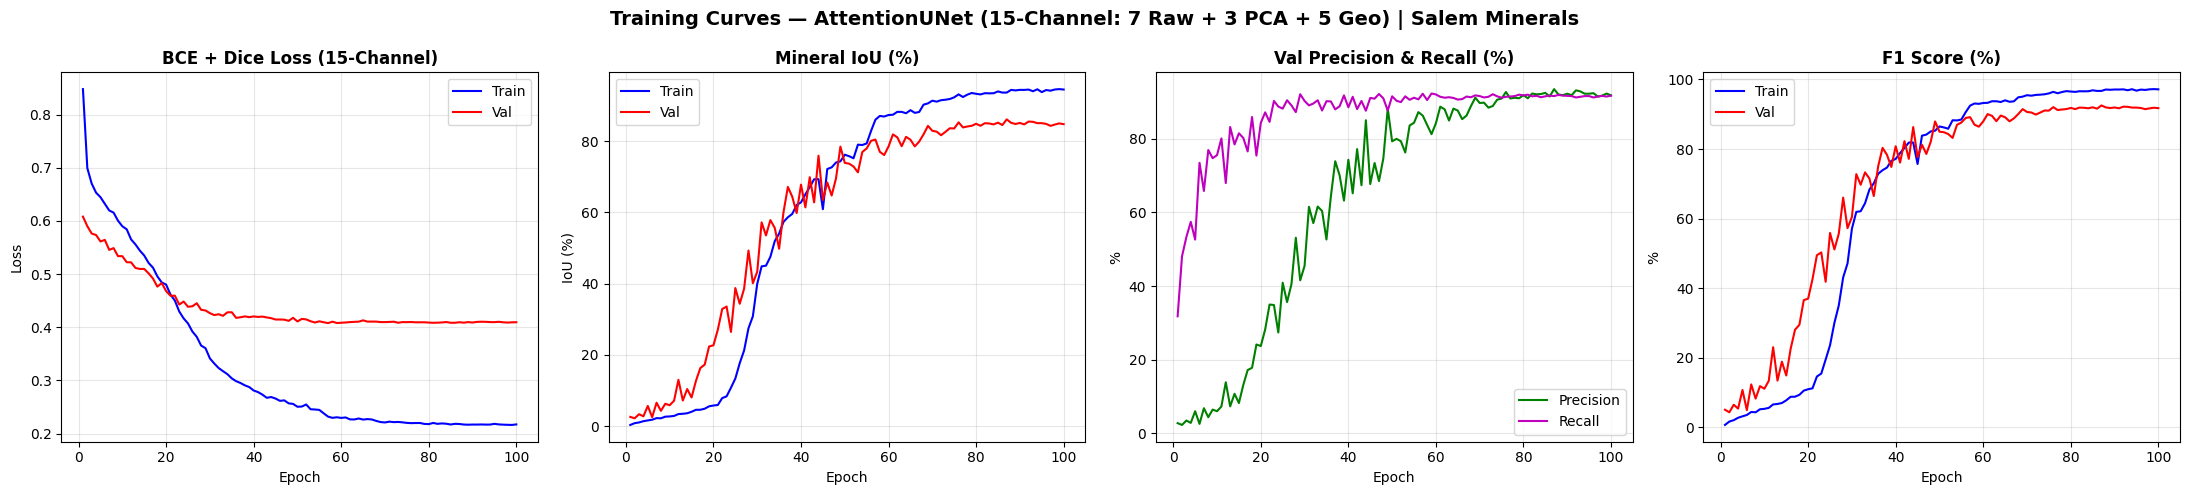

In [12]:
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].plot(ep, history['train_loss'], 'b-', label='Train')
axes[0].plot(ep, history['val_loss'],   'r-', label='Val')
axes[0].set_title('BCE + Dice Loss (15-Channel)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [v*100 for v in history['train_min_iou']], 'b-', label='Train')
axes[1].plot(ep, [v*100 for v in history['val_min_iou']],   'r-', label='Val')
axes[1].set_title('Mineral IoU (%)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, [v*100 for v in history['val_precision']], 'g-', label='Precision')
axes[2].plot(ep, [v*100 for v in history['val_recall']],    'm-', label='Recall')
axes[2].set_title('Val Precision & Recall (%)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('%')
axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(ep, [v*100 for v in history['train_f1']], 'b-', label='Train')
axes[3].plot(ep, [v*100 for v in history['val_f1']],   'r-', label='Val')
axes[3].set_title('F1 Score (%)', fontweight='bold')
axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('%')
axes[3].legend(); axes[3].grid(alpha=0.3)

plt.suptitle('Training Curves — AttentionUNet (15-Channel: 7 Raw + 3 PCA + 5 Geo) | Salem Minerals',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_raw_pca_geo.png', dpi=150, bbox_inches='tight')
plt.show()

### Threshold Search on Validation Set

In [13]:
# No threshold search — use the same threshold as training
BEST_THRESHOLD = THRESHOLD
print(f"Using fixed training threshold: BEST_THRESHOLD = {BEST_THRESHOLD:.2f}")

Using fixed training threshold: BEST_THRESHOLD = 0.30


### Test Set Evaluation

In [14]:
# ── Results at FIXED threshold (baseline)
(fix_loss, fix_acc, fix_miou, fix_min_iou,
 fix_precision, fix_recall, fix_f1) = evaluate_efficient(
    model, test_loader, criterion,
    threshold=THRESHOLD, device=DEVICE
)

print(" TEST SET RESULTS — 15-Channel AttentionUNet (7 Raw + 3 PCA + 5 Geo)")

print(f"\n── At FIXED threshold = {THRESHOLD:.2f}  [Baseline — no val optimisation] ──")
print(f"  ★ Mineral IoU (PRIMARY) : {fix_min_iou*100:.2f}%")
print(f"  ★ F1 Score   (PRIMARY)  : {fix_f1*100:.2f}%")
print(f"  ★ Recall                : {fix_recall*100:.2f}%")
print(f"  ★ Precision             : {fix_precision*100:.2f}%")
print(f"    Mean IoU  (secondary) : {fix_miou*100:.2f}%")
print(f"    Loss                  : {fix_loss:.4f}")
print(f"    Pixel Acc (secondary) : {fix_acc*100:.2f}% ")

 TEST SET RESULTS — 15-Channel AttentionUNet (7 Raw + 3 PCA + 5 Geo)

── At FIXED threshold = 0.30  [Baseline — no val optimisation] ──
  ★ Mineral IoU (PRIMARY) : 85.53%
  ★ F1 Score   (PRIMARY)  : 92.20%
  ★ Recall                : 90.17%
  ★ Precision             : 94.33%
    Mean IoU  (secondary) : 92.76%
    Loss                  : 0.3950
    Pixel Acc (secondary) : 99.98% 


### Visualize Test Patch Predictions

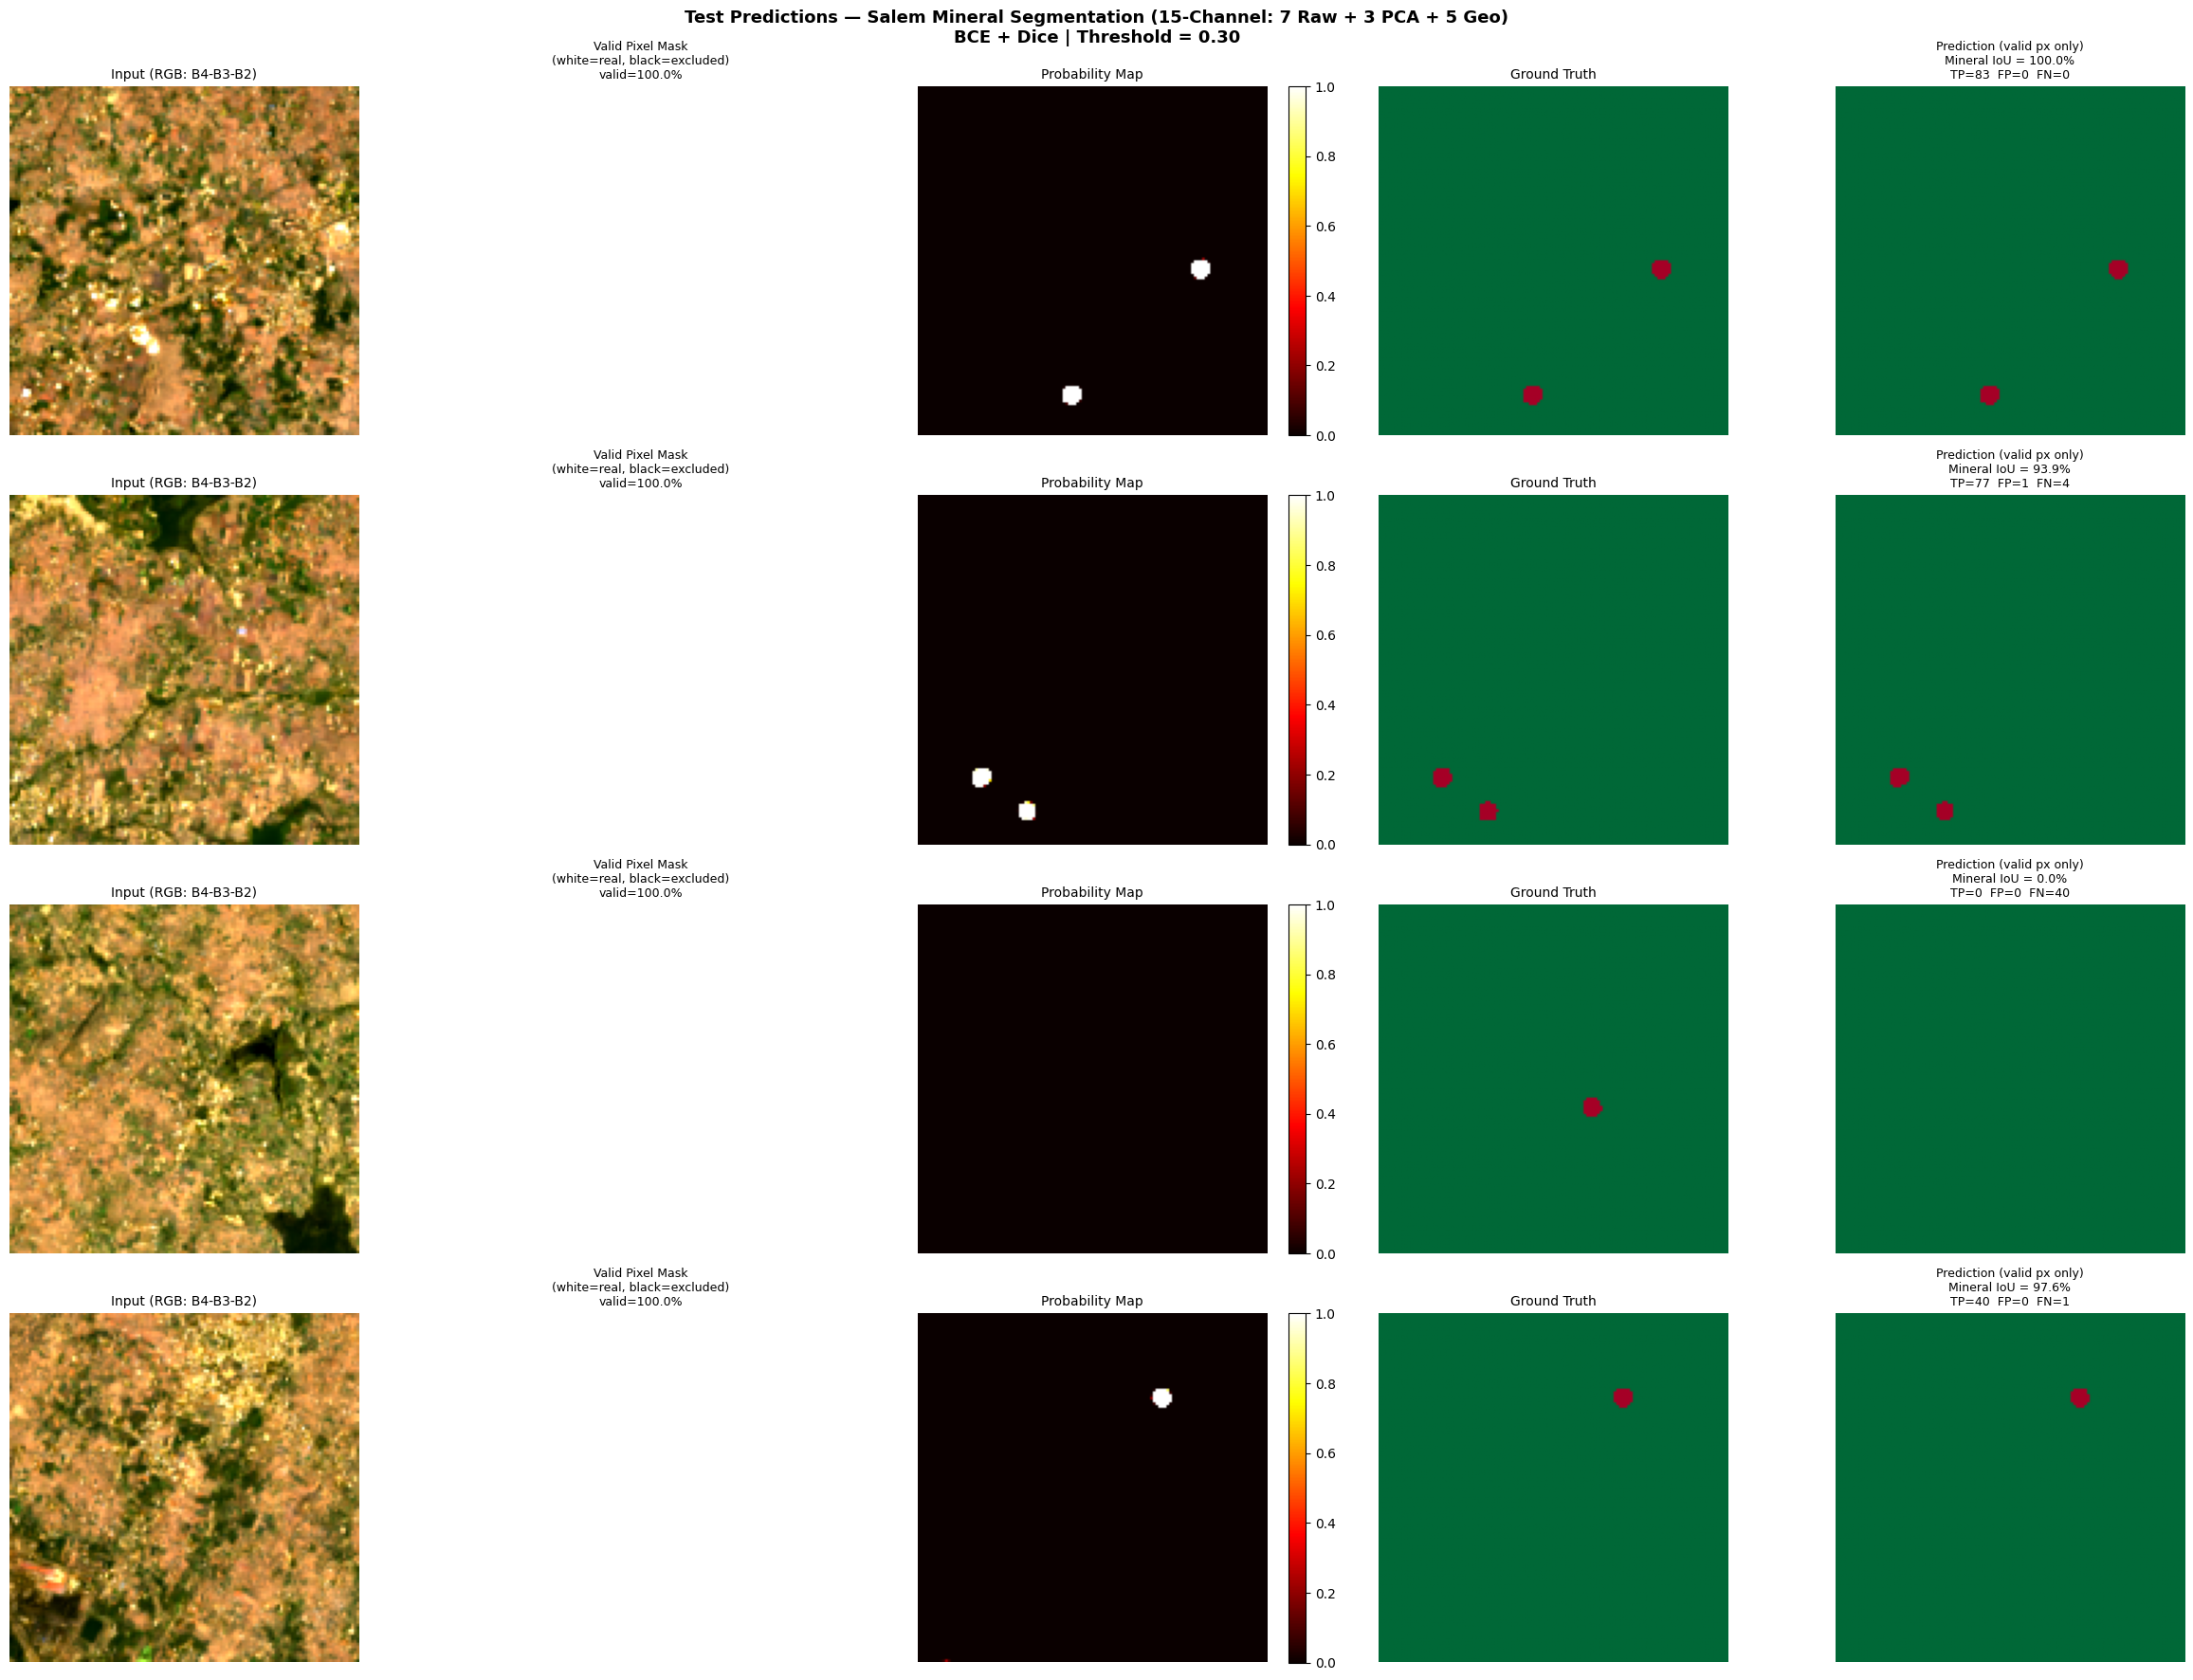

In [15]:
# Find mineral patches in the test set
mineral_test_idx = [
    i for i in range(len(test_ds))
    if test_ds.labels[i].sum() > 0
]

n_show = min(4, len(mineral_test_idx))
if n_show == 0:
    print("No mineral patches in test set to visualize.")
else:
    sample = random.sample(mineral_test_idx, n_show)
    # 5 columns: Input | Valid Mask | Probability Map | Ground Truth | Prediction
    fig, axes = plt.subplots(n_show, 5, figsize=(24, n_show * 4.5))
    if n_show == 1:
        axes = axes[np.newaxis, :]

    model.eval()
    for row, i in enumerate(sample):
        img_t, lbl_t, valid_t = test_ds[i]
        img_t = img_t.to(DEVICE)

        with torch.no_grad():
            logits = model(img_t.unsqueeze(0))
            prob   = torch.sigmoid(logits).squeeze().cpu().numpy()

        pred_bin = (prob > BEST_THRESHOLD).astype(np.uint8)
        lbl_np   = lbl_t.squeeze().cpu().numpy()
        valid_np = valid_t.squeeze().numpy().astype(bool)

        # Undo normalization → make RGB from raw bands B4, B3, B2 (channels 3, 2, 1)
        img_np  = img_t.cpu().permute(1, 2, 0).numpy() * band_stds + band_means
        rgb_vis = img_np[:, :, [3, 2, 1]]   # channels 3,2,1 = B4,B3,B2 (raw spectral bands)
        p2, p98 = np.percentile(rgb_vis, (2, 98))
        rgb_vis = np.clip((rgb_vis - p2) / (p98 - p2 + 1e-8), 0, 1)

        # Col 0: Input image
        axes[row, 0].imshow(rgb_vis)
        axes[row, 0].set_title("Input (RGB: B4-B3-B2)", fontsize=10)
        axes[row, 0].axis("off")

        # Col 1: Valid pixel mask
        axes[row, 1].imshow(valid_np, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title(
            f"Valid Pixel Mask\n(white=real, black=excluded)\nvalid={valid_np.mean()*100:.1f}%",
            fontsize=9
        )
        axes[row, 1].axis("off")

        # Col 2: Probability map
        im = axes[row, 2].imshow(prob, cmap="hot", vmin=0, vmax=1)
        axes[row, 2].set_title("Probability Map", fontsize=10)
        axes[row, 2].axis("off")
        plt.colorbar(im, ax=axes[row, 2], fraction=0.046)

        # Col 3: Ground truth
        axes[row, 3].imshow(lbl_np, cmap="RdYlGn_r", vmin=0, vmax=1)
        axes[row, 3].set_title("Ground Truth", fontsize=10)
        axes[row, 3].axis("off")

        # Col 4: Prediction — IoU computed on valid pixels only
        p_v = pred_bin[valid_np]
        t_v = lbl_np[valid_np].astype(np.uint8)
        tp_p = int(((p_v == 1) & (t_v == 1)).sum())
        fp_p = int(((p_v == 1) & (t_v == 0)).sum())
        fn_p = int(((p_v == 0) & (t_v == 1)).sum())
        iou_p = tp_p / (tp_p + fp_p + fn_p + 1e-8)

        axes[row, 4].imshow(pred_bin, cmap="RdYlGn_r", vmin=0, vmax=1)
        axes[row, 4].set_title(
            f"Prediction (valid px only)\nMineral IoU = {iou_p*100:.1f}%\nTP={tp_p}  FP={fp_p}  FN={fn_p}",
            fontsize=9
        )
        axes[row, 4].axis("off")

    plt.suptitle(
        f"Test Predictions — Salem Mineral Segmentation (15-Channel: 7 Raw + 3 PCA + 5 Geo)\n"
        f"BCE + Dice | Threshold = {BEST_THRESHOLD:.2f}",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "test_mineral_patches_raw_pca_geo.png", dpi=150, bbox_inches="tight")
    plt.show()

### Confusion Matrices — Train, Val & Test

  26,938,662 / 27,394,048 pixels used (98.3% valid, 455,386 border excluded)
  918,171 / 933,888 pixels used (98.3% valid, 15,717 border excluded)
  976,662 / 983,040 pixels used (99.4% valid, 6,378 border excluded)
 CONFUSION MATRIX REPORT — 15-Channel AttentionUNet (7 Raw + 3 PCA + 5 Geo)
 Threshold = 0.30

── TRAIN SET (26,938,662 pixels total) ──
                            Predicted BG   Predicted Mineral
  True BG                   TN=  26,868,440   FP=       4,156
  True Mineral              FN=           3   TP=      66,063

  Accuracy    : 99.9846%
  Precision   : 94.0814%
  Recall      : 99.9955%
  Specificity : 99.9845%
  F1 Score    : 96.9483%
  Mineral IoU : 94.0774%
  Mean IoU    : 97.0309%

── VAL SET (918,171 pixels total) ──
                            Predicted BG   Predicted Mineral
  True BG                   TN=     916,487   FP=         101
  True Mineral              FN=         133   TP=       1,450

  Accuracy    : 99.9745%
  Precision   : 93.4881%
  Recall    

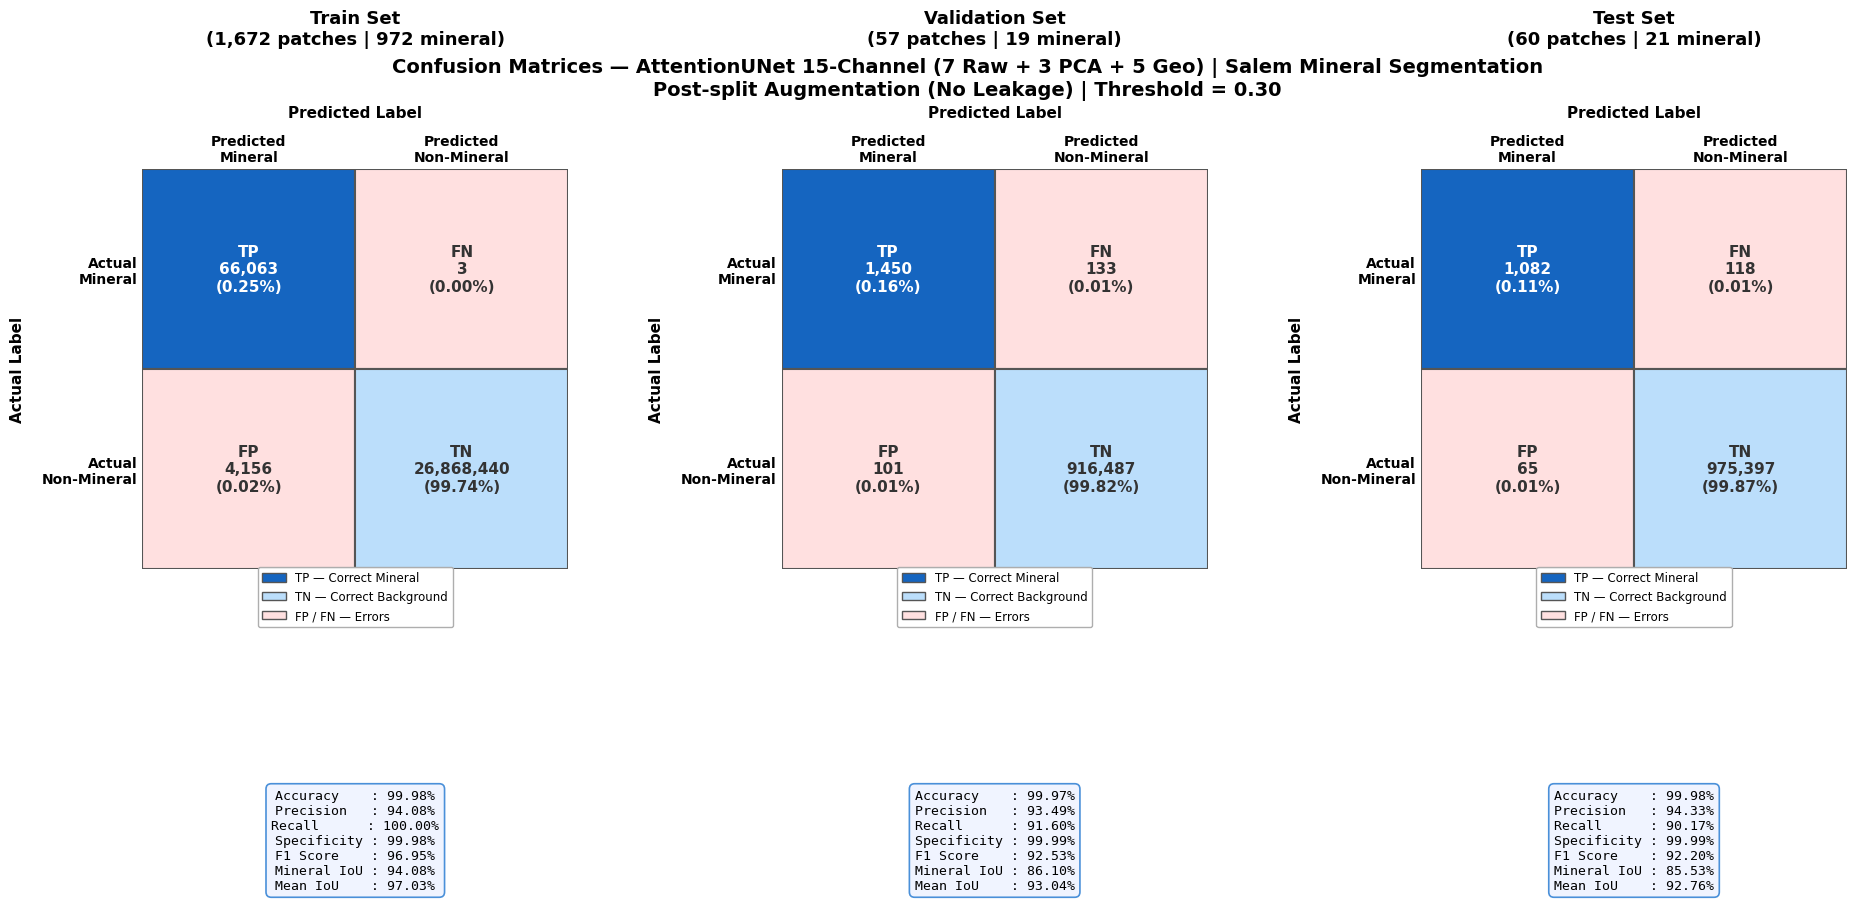


Saved: /content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1/results_raw_pca_geo_final/confusion_matrices_raw_pca_geo.png


In [16]:
import matplotlib.ticker as mticker

def collect_confusion(model, loader, threshold, device):
    """Accumulate TP/FP/FN/TN over an entire dataloader — valid pixels only."""
    model.eval()
    tp = fp = fn = tn = 0
    total_px = valid_px = 0

    with torch.no_grad():
        for imgs, lbls, valids in loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device)

            probs     = torch.sigmoid(model(imgs))
            preds_bin = (probs > threshold).float()

            p = preds_bin.cpu().numpy().reshape(-1).astype(np.int32)
            t = lbls.cpu().numpy().reshape(-1).astype(np.int32)
            v = valids.cpu().numpy().reshape(-1).astype(bool)

            total_px += len(v)
            valid_px += int(v.sum())

            p, t = p[v], t[v]

            tp += int(((p == 1) & (t == 1)).sum())
            fp += int(((p == 1) & (t == 0)).sum())
            fn += int(((p == 0) & (t == 1)).sum())
            tn += int(((p == 0) & (t == 0)).sum())

            del imgs, lbls, valids, probs, preds_bin
            torch.cuda.empty_cache()

    print(f"  {valid_px:,} / {total_px:,} pixels used "
          f"({valid_px/total_px*100:.1f}% valid, {total_px-valid_px:,} border excluded)")
    return tp, fp, fn, tn


def metrics_from_cm(tp, fp, fn, tn, smooth=1e-8):
    precision   = (tp + smooth) / (tp + fp + smooth)
    recall      = (tp + smooth) / (tp + fn + smooth)
    f1          = 2 * precision * recall / (precision + recall + smooth)
    mineral_iou = (tp + smooth) / (tp + fp + fn + smooth)
    bg_iou      = (tn + smooth) / (tn + fp + fn + smooth)
    mean_iou    = (mineral_iou + bg_iou) / 2
    accuracy    = (tp + tn) / (tp + fp + fn + tn + smooth)
    specificity = (tn + smooth) / (tn + fp + smooth)
    return {
        'accuracy'   : float(accuracy),
        'precision'  : float(precision),
        'recall'     : float(recall),
        'specificity': float(specificity),
        'f1'         : float(f1),
        'mineral_iou': float(mineral_iou),
        'mean_iou'   : float(mean_iou),
    }


def plot_cm(ax, tp, fp, fn, tn, title, metrics):
    import matplotlib.patches as _mp

    total  = tp + fp + fn + tn + 1e-8
    pcts   = [[tp/total*100, fn/total*100],
              [fp/total*100, tn/total*100]]
    counts = [[tp, fn], [fp, tn]]
    names  = [["TP", "FN"], ["FP", "TN"]]

    DARK_BLUE  = "#1565C0"
    LIGHT_BLUE = "#BBDEFB"
    LIGHT_RED  = "#FFE0E0"
    cell_fc = [[DARK_BLUE,  LIGHT_RED],
               [LIGHT_RED,  LIGHT_BLUE]]
    txt_clr = [["white",   "#333333"],
               ["#333333", "#333333"]]

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)

    for row in range(2):
        for col in range(2):
            rect = _mp.FancyBboxPatch(
                (col - 0.5, row - 0.5), 1.0, 1.0,
                boxstyle="square,pad=0",
                facecolor=cell_fc[row][col],
                edgecolor="#555555", linewidth=1.5,
                transform=ax.transData, zorder=1
            )
            ax.add_patch(rect)
            ax.text(
                col, row,
                f"{names[row][col]}\n{counts[row][col]:,}\n({pcts[row][col]:.2f}%)",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color=txt_clr[row][col], zorder=2
            )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Predicted\nMineral", "Predicted\nNon-Mineral"],
                       fontsize=10, fontweight="bold")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Actual\nMineral", "Actual\nNon-Mineral"],
                       fontsize=10, fontweight="bold")
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Predicted Label", fontsize=11, fontweight="bold", labelpad=12)
    ax.set_ylabel("Actual Label",    fontsize=11, fontweight="bold", labelpad=12)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=44)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    legend_patches = [
        _mp.Patch(facecolor=DARK_BLUE,  edgecolor="#555", label="TP — Correct Mineral"),
        _mp.Patch(facecolor=LIGHT_BLUE, edgecolor="#555", label="TN — Correct Background"),
        _mp.Patch(facecolor=LIGHT_RED,  edgecolor="#555", label="FP / FN — Errors"),
    ]
    ax.legend(handles=legend_patches, loc="lower center",
              bbox_to_anchor=(0.5, -0.16), ncol=1,
              fontsize=8.5, framealpha=0.95, edgecolor="#aaa")

    metrics_text = (
        f"Accuracy    : {metrics['accuracy']*100:.2f}%\n"
        f"Precision   : {metrics['precision']*100:.2f}%\n"
        f"Recall      : {metrics['recall']*100:.2f}%\n"
        f"Specificity : {metrics['specificity']*100:.2f}%\n"
        f"F1 Score    : {metrics['f1']*100:.2f}%\n"
        f"Mineral IoU : {metrics['mineral_iou']*100:.2f}%\n"
        f"Mean IoU    : {metrics['mean_iou']*100:.2f}%"
    )
    ax.text(0.5, -0.55, metrics_text,
            transform=ax.transAxes, ha="center", va="top",
            fontsize=9.5, family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f4ff",
                      edgecolor="#4a90d9", linewidth=1.2))


# ── Collect confusion counts
print("Collecting predictions for Train set...")
tr_tp, tr_fp, tr_fn, tr_tn = collect_confusion(model, train_loader, BEST_THRESHOLD, DEVICE)
gc.collect(); torch.cuda.empty_cache()

print("Collecting predictions for Val set...")
v_tp, v_fp, v_fn, v_tn = collect_confusion(model, val_loader, BEST_THRESHOLD, DEVICE)
gc.collect(); torch.cuda.empty_cache()

print("Collecting predictions for Test set...")
t_tp, t_fp, t_fn, t_tn = collect_confusion(model, test_loader, BEST_THRESHOLD, DEVICE)
gc.collect(); torch.cuda.empty_cache()

# ── Compute metrics
tr_metrics = metrics_from_cm(tr_tp, tr_fp, tr_fn, tr_tn)
v_metrics  = metrics_from_cm(v_tp,  v_fp,  v_fn,  v_tn)
t_metrics  = metrics_from_cm(t_tp,  t_fp,  t_fn,  t_tn)

# ── Text report
print(" CONFUSION MATRIX REPORT — 15-Channel AttentionUNet (7 Raw + 3 PCA + 5 Geo)")
print(f" Threshold = {BEST_THRESHOLD:.2f}")

for split_name, tp, fp, fn, tn, m in [
    ("TRAIN", tr_tp, tr_fp, tr_fn, tr_tn, tr_metrics),
    ("VAL",   v_tp,  v_fp,  v_fn,  v_tn,  v_metrics),
    ("TEST",  t_tp,  t_fp,  t_fn,  t_tn,  t_metrics),
]:
    total = tp + fp + fn + tn
    print(f"\n── {split_name} SET ({total:,} pixels total) ──")
    print(f"  {'':25} Predicted BG   Predicted Mineral")
    print(f"  {'True BG':25} TN={tn:>12,}   FP={fp:>12,}")
    print(f"  {'True Mineral':25} FN={fn:>12,}   TP={tp:>12,}")
    print(f"\n  Accuracy    : {m['accuracy']*100:.4f}%")
    print(f"  Precision   : {m['precision']*100:.4f}%")
    print(f"  Recall      : {m['recall']*100:.4f}%")
    print(f"  Specificity : {m['specificity']*100:.4f}%")
    print(f"  F1 Score    : {m['f1']*100:.4f}%")
    print(f"  Mineral IoU : {m['mineral_iou']*100:.4f}%")
    print(f"  Mean IoU    : {m['mean_iou']*100:.4f}%")


# ── Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.subplots_adjust(bottom=0.38, wspace=0.5)

plot_cm(axes[0],
        tr_tp, tr_fp, tr_fn, tr_tn,
        f"Train Set\n({len(train_ds):,} patches | {int(train_tags.sum())} mineral)",
        tr_metrics)

plot_cm(axes[1],
        v_tp, v_fp, v_fn, v_tn,
        f"Validation Set\n({len(val_ds):,} patches | {int(val_tags.sum())} mineral)",
        v_metrics)

plot_cm(axes[2],
        t_tp, t_fp, t_fn, t_tn,
        f"Test Set\n({len(test_ds):,} patches | {int(test_tags.sum())} mineral)",
        t_metrics)

plt.suptitle(
    "Confusion Matrices — AttentionUNet 15-Channel (7 Raw + 3 PCA + 5 Geo) | Salem Mineral Segmentation\n"
    f"Post-split Augmentation (No Leakage) | Threshold = {BEST_THRESHOLD:.2f}",
    fontsize=14, fontweight='bold', y=1.02
)

plt.savefig(RESULTS_DIR / 'confusion_matrices_raw_pca_geo.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {RESULTS_DIR / 'confusion_matrices_raw_pca_geo.png'}")

In [ ]:
import time, os

print("Session will terminate in 10 seconds...")
time.sleep(10)
os.kill(os.getpid(), 9)

Session will terminate in 10 seconds...
